# Crack growth rate

This example demonstrates how to compute the rate of advancing the crack using the asymptotic approach, and compares with Monte Carlo calculations results.

## Isometric ensemble

This is first done in the isometric thermodynamic ensemble. The crack growth rate will be computed for a set of increasing nondimensional bond energies:

In [1]:
varepsilons = [10, 25, 100, 1000]

Now the rate (relative to the initial rate) is computed as a function of the nondimensional end separation in a loop for each model. The default calculation approach is asymptotic:

In [2]:
import numpy as np
from statmechcrack import Crack

v = np.linspace(1, 11, 33)
k_asymptotic = np.zeros((33, len(varepsilons)))
for i, varepsilon in enumerate(varepsilons):
    model = Crack(varepsilon=varepsilon)
    k_asymptotic[:, i] = model.k(v, ensemble='isometric')

Monte Carlo is another calculation approach and does not make approximations, but takes a considerable amount of time. These calculations have already been performed, and the results archived in the local data folder. The steps to obtain these results are commented below, and the results are simply loaded instead:

In [3]:
k_monte_carlo = np.zeros((33, len(varepsilons)))
for i, varepsilon in enumerate(varepsilons):
#     model = Crack(varepsilon=varepsilon)
#     k_monte_carlo[:, i] = model.k(
#         v, ensemble='isometric', approach='monte carlo',
#         num_processes=32, num_samples=int(3.125e7))
    k_monte_carlo[:, i] = np.load(
        'data/k_monte_carlo_isometric_varepsilon_'
        + str(varepsilon) + '.npy')[2]

The results can now be plotted together:

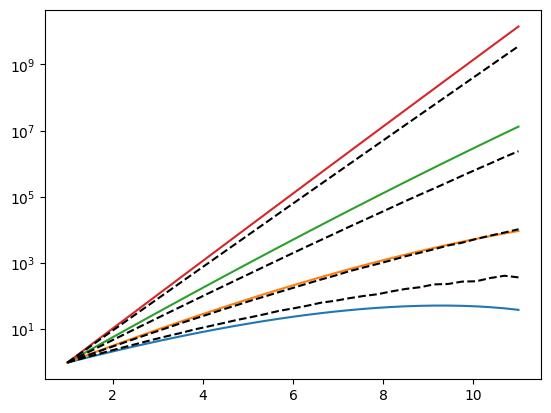

In [4]:
import matplotlib.pyplot as plt

_ = plt.semilogy(v, k_asymptotic)
_ = plt.semilogy(v, k_monte_carlo, 'k--')

## Isotensional ensemble

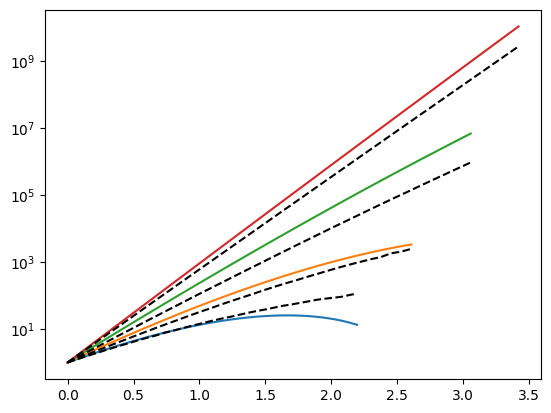

In [5]:
p = np.zeros((33, len(varepsilons)))
for i, varepsilon in enumerate(varepsilons):
    model = Crack(varepsilon=varepsilon)
    p[:, i] = model.p(v, ensemble='isometric')
    k_asymptotic[:, i] = model.k(p[:, i], ensemble='isotensional')
#     model = Crack(varepsilon=varepsilon)
#     k_monte_carlo[:, i] = model.k(
#         v, ensemble='isotensional', approach='monte carlo',
#         num_processes=32, num_samples=int(3.125e7))
    k_monte_carlo[:, i] = np.load(
        'data/k_monte_carlo_isotensional_varepsilon_'
        + str(varepsilon) + '.npy')[2]
_ = plt.semilogy(p, k_asymptotic)
_ = plt.semilogy(p, k_monte_carlo, 'k--')